In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("../resultados/resultados_tests.csv")

potencia = (
    df.groupby(["escenario", "metodo"])["resultado"]
    .mean()
    .mul(100)
    .reset_index(name="porcentaje")
)

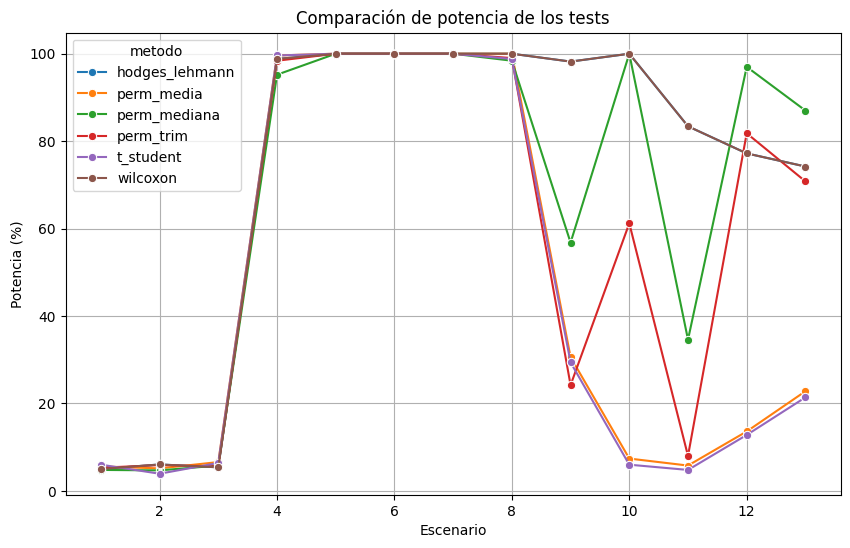

In [2]:
plt.figure(figsize=(10,6))

sns.lineplot(
    data=potencia,
    x="escenario",
    y="porcentaje",
    hue="metodo",
    marker="o"
)

plt.ylabel("Potencia (%)")
plt.xlabel("Escenario")
plt.title("Comparación de potencia de los tests")
plt.grid(True)

plt.show()

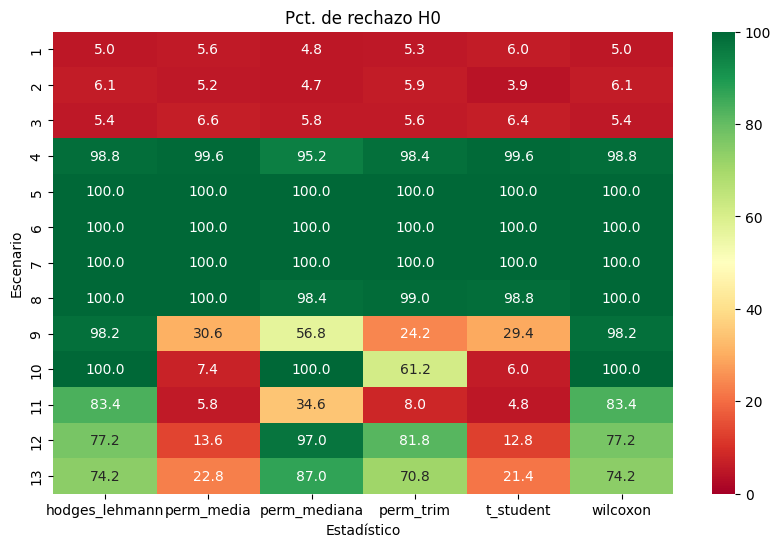

In [8]:
tabla = potencia.pivot(
    index="escenario",
    columns="metodo",
    values="porcentaje"
)

plt.figure(figsize=(10,6))

sns.heatmap(
    tabla,
    annot=True,
    fmt=".1f",
    cmap="RdYlGn",   # rojo → amarillo → verde
    vmin=0,
    vmax=100
)

plt.title("Pct. de rechazo H0")
plt.xlabel("Estadístico")
plt.ylabel("Escenario")

plt.show()

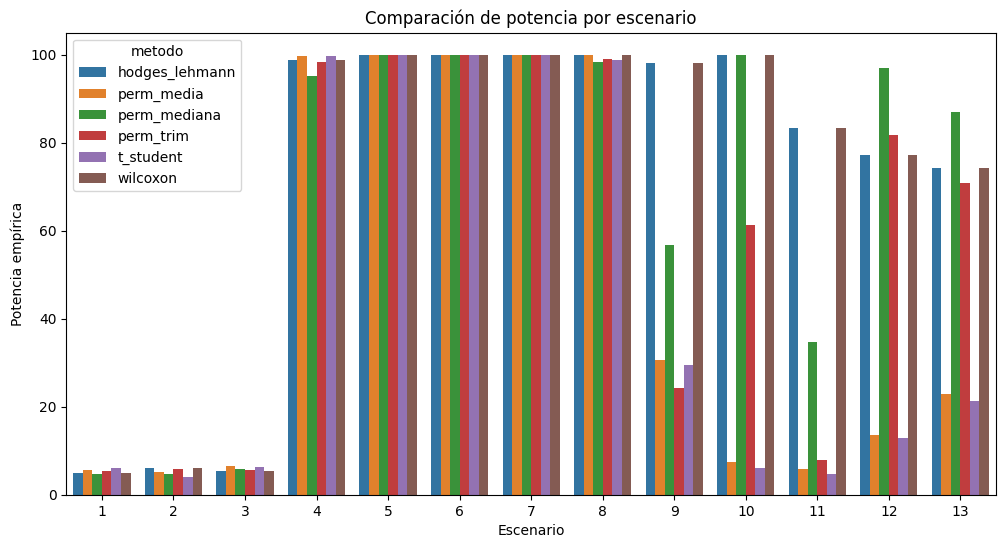

In [9]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=potencia,
    x="escenario",
    y="porcentaje",
    hue="metodo"
)

plt.ylabel("Potencia empírica")
plt.xlabel("Escenario")
plt.title("Comparación de potencia por escenario")

plt.show()